In [3]:
%load_ext autoreload
%autoreload 2

import os
import cv2
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import transforms
from models import load_model_unet
from losses import WeightedDiceLoss
import random
from torch.utils.data import Dataset, DataLoader
from glob import glob
import xml.etree.ElementTree as ET
import albumentations as A
import numpy as np
from torch.utils.tensorboard import SummaryWriter

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


device(type='cpu')

In [2]:
BATCH_SIZE = 32

collab = False
if collab:
    from google.colab import drive

    drive.mount('/content/drive')
    folder_path = 'drive/MyDrive/ai_data/data'
else:
    folder_path = './'

checkpoint_in_path = os.path.join(folder_path, 'checkpoints/unet.pth') 
checkpoint_out_path = os.path.join(folder_path, 'checkpoints/competition_finetuned_unet.pth')

flags_path = os.path.join(folder_path, './competition/data/raw_frames')
annots_xml_path = os.path.join(folder_path, './competition/data/annots/annotations.xml')

/home/zeyadcode/.pyenv/versions/aienv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


TypeError: Invalid shape (1, 512, 512) for image data

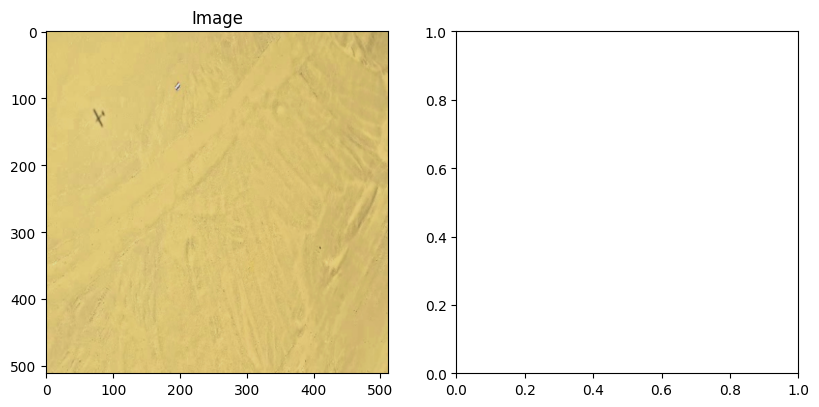

In [23]:
class CompetetionDataset(Dataset):
    def __init__(self, flags_path, annots_xml_path, augment=False):
        self.flags = sorted(glob(os.path.join(flags_path, "*.jpg")))
        self.xml_annots = ET.parse(annots_xml_path).getroot()
        self.frame_to_boxes = {}
        for track in self.xml_annots.findall("track"):
            for box in track.findall("box"):
                if box.get("outside") == "0":
                    frame = int(box.get("frame"))
                    coords = (
                        float(box.get("xtl")),
                        float(box.get("ytl")),
                        float(box.get("xbr")),
                        float(box.get("ybr"))
                    )
                    self.frame_to_boxes.setdefault(frame, []).append(coords)
        self.augment = augment
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.5),
            A.HueSaturationValue(hue_shift_limit=30, sat_shift_limit=40, val_shift_limit=30, p=0.5),
            A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=0.5),
            A.RandomGamma(gamma_limit=(60, 140), p=0.3),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.2),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.Resize(512, 512, p=1.0),
        ])

    def __len__(self):
        return len(self.flags)

    def __getitem__(self, idx):
        flag_path = self.flags[idx]
        flag = cv2.imread(flag_path)
        flag = cv2.cvtColor(flag, cv2.COLOR_BGR2RGB)
        mask = np.zeros((flag.shape[0], flag.shape[1]), dtype=np.float32)
        boxes = self.frame_to_boxes.get(idx, [])
        for x1, y1, x2, y2 in boxes:
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            mask[y1:y2, x1:x2] = 1.0

        if self.augment:
            augmented = self.transform(image=flag, mask=mask)
            flag, mask = augmented['image'], augmented['mask']
            # If any mask pixel is out of bounds (i.e., mask is cropped out), set mask to all zeros
            if mask.sum() == 0 or np.any(mask < 0) or np.any(mask > 1):
                mask = np.zeros_like(mask)
        
        flag = torch.from_numpy(flag).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).float().unsqueeze(0)
        label = 1 if len(boxes) > 0 else 0

        return flag, mask, label

dataset = CompetetionDataset(flags_path, annots_xml_path, augment=True)

# Calculate sample weights for WeightedRandomSampler
labels = [1 if len(dataset.frame_to_boxes.get(i, [])) > 0 else 0 for i in range(len(dataset))]
class_sample_count = np.array([len(np.where(np.array(labels) == t)[0]) for t in [0, 1]])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in labels])
samples_weight = torch.from_numpy(samples_weight).float()
sampler = torch.utils.data.WeightedRandomSampler(samples_weight, len(samples_weight))

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler)

img, mask, label = dataset[2380]

plt.figure(figsize=(15, 5), dpi=100)

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title("Image")

plt.subplot(1, 3, 2)
plt.imshow(mask.numpy())
plt.title("Mask")

plt.subplot(1, 3, 3)
plt.imshow(img.permute(1, 2, 0) * mask.unsqueeze(dim=0).permute(1, 2, 0).numpy())
plt.title("Multiplied")

In [ ]:
model = load_model_unet(checkpoint_in_path)
for param in model.parameters():
    param.requires_grad = False
    
for param in model.conv.parameters(): # type: ignore
    param.requires_grad = True

Using cache found in /home/zeyadcode/.cache/torch/hub/mateuszbuda_brain-segmentation-pytorch_master


In [24]:
writer = SummaryWriter()

criterion = WeightedDiceLoss(foreground_weight=50)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 100
model.train()

for epoch in range(epochs):
    model.to(device)
    loss_avg = 0
    dice_scores = []
    
    for img, mask, label in dataloader:
        mask_pred = model(img)
        loss = criterion(mask_pred, mask)
        
        # Log Dice score as 1 - loss (matches WeightedDiceLoss)
        dice_score = 1.0 - loss.item()
        dice_scores.append(dice_score)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_avg += loss.item()

    avg_dice = sum(dice_scores) / len(dice_scores)
    writer.add_scalar('Loss/train', loss_avg, epoch)
    writer.add_scalar('Dice/train', avg_dice, epoch)
    print(f'Epoch {epoch}, loss_avg {loss_avg}, dice {avg_dice:.4f}')
    torch.save(model.state_dict(), checkpoint_out_path)

writer.close()

KeyboardInterrupt: 